# 🔄 Notebook 10: Model Conversion & ONNX Serving Validation — WASTRA AI BATIK

Notebook ini adalah tahap **Deployment Engineering** setelah Notebook 09.
Tujuan utamanya adalah melakukan konversi model final **EfficientNetB0 Fine-Tuned** dari format `.keras` ke **ONNX (`.onnx`)**, memvalidasi integritas ONNX graph, dan memastikan eksekusi **ONNX Runtime** menghasilkan prediksi yang 100% konsisten dan numerik identik dengan **Keras** sebelum diintegrasikan ke **Backend Go (REST API)**.

---

### 🎯 Tujuan & Validasi Utama:
1. **Load Final Model**: Menggunakan `training/saved_models/efficientnetb0_finetuned.keras` (86.05% Test Accuracy, 0.8667 Macro F1).
2. **Convert to ONNX**: Konversi graph model menggunakan `tf2onnx` ke `training/saved_models/efficientnetb0_finetuned.onnx`.
3. **Validate ONNX Graph**: Memeriksa integritas graph menggunakan `onnx.checker.check_model()`.
4. **ONNX Runtime Serving**: Menjalankan session inference menggunakan `onnxruntime.InferenceSession`.
5. **Keras vs ONNX Consistency**: Memverifikasi Top-1/Top-3/Top-5 agreement dan maximum numerical probability difference ($< 10^{-4}$).
6. **Benchmark Latency & Throughput**: Membandingkan latensi Keras vs ONNX Runtime pada CPU.
7. **Sign-off Go Backend Readiness**: Validasi 10-point checklist untuk integrasi ke Backend Go.

---

### 📋 16 Comprehensive Sections:
1. **Environment & Path Verification**
2. **Verify Required Dependencies**
3. **Load Final Keras Model**
4. **Load Class Mapping**
5. **Verify Preprocessing**
6. **Baseline Keras Inference**
7. **Convert Keras -> ONNX**
8. **Load ONNX Model**
9. **Keras vs ONNX Inference Comparison**
10. **Numerical Output Validation**
11. **Top-K Consistency Test**
12. **Visual Comparison**
13. **Inference Benchmark**
14. **Go Backend Readiness**
15. **Deployment Artifact Audit**
16. **Final Verdict**


## ⚙️ Section 1 — Environment & Path Verification


In [1]:
import os
import sys
import time
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deterministic CPU configuration
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf
import keras
import tf2onnx
import onnx
import onnxruntime as ort

tf.random.set_seed(42)
np.random.seed(42)

BASE_DIR = Path.cwd().resolve().parent.parent if "training" in str(Path.cwd()) else Path.cwd().resolve()
DATASETS_DIR = BASE_DIR / "datasets" / "processed"
MODELS_DIR = BASE_DIR / "training" / "saved_models"
RESULTS_DIR = BASE_DIR / "results"

metadata_path = DATASETS_DIR / "split_metadata.csv"
keras_model_path = MODELS_DIR / "efficientnetb0_finetuned.keras"
onnx_model_path = MODELS_DIR / "efficientnetb0_finetuned.onnx"
class_mapping_path = RESULTS_DIR / "efficientnetb0_class_mapping.json"
model_metadata_path = RESULTS_DIR / "efficientnetb0_model_metadata.json"

print(f"• Base Directory     : {BASE_DIR}")
print(f"• Python Executable  : {sys.executable}")
print(f"• Python Version     : {sys.version.split()[0]}")
print(f"• TensorFlow Version : {tf.__version__}")
print(f"• Keras Version      : {keras.__version__}")
print(f"• Model Path         : {keras_model_path}")
print(f"• Results Directory  : {RESULTS_DIR}")

assert keras_model_path.exists(), f"❌ Keras model not found: {keras_model_path}"
assert metadata_path.exists(), f"❌ Split metadata not found: {metadata_path}"

print("\nSTATUS: ENVIRONMENT VERIFICATION    PASS [OK]")


• Base Directory     : C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik
• Python Executable  : C:\Users\dzaki\AppData\Local\Programs\Python\Python39\python.exe
• Python Version     : 3.9.0
• TensorFlow Version : 2.10.1
• Keras Version      : 3.10.0
• Model Path         : C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\training\saved_models\efficientnetb0_finetuned.keras
• Results Directory  : C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\results

STATUS: ENVIRONMENT VERIFICATION    PASS [OK]


## 📦 Section 2 — Verify Required Dependencies


In [2]:
import PIL
dependencies = {
    "tensorflow": tf.__version__,
    "keras": keras.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "PIL": PIL.__version__,
    "onnx": onnx.__version__,
    "onnxruntime": ort.__version__,
    "tf2onnx": tf2onnx.__version__
}

print("VERIFIED PACKAGE VERSIONS:")
print("-" * 35)
for pkg_name, ver in dependencies.items():
    print(f"• {pkg_name:<16} : {ver}")

print("\nSTATUS: DEPENDENCIES VERIFICATION   PASS [OK]")


VERIFIED PACKAGE VERSIONS:
-----------------------------------
• tensorflow       : 2.10.1
• keras            : 3.10.0
• numpy            : 1.23.5
• pandas           : 2.3.3
• PIL              : 11.3.0
• onnx             : 1.17.0
• onnxruntime      : 1.19.2
• tf2onnx          : 1.16.1

STATUS: DEPENDENCIES VERIFICATION   PASS [OK]


## 🏗️ Section 3 — Load Final Keras Model


In [3]:
print(f"Loading {keras_model_path.name} (compile=False)...")
keras_model = keras.models.load_model(keras_model_path, compile=False)

input_shape = keras_model.input_shape
output_shape = keras_model.output_shape
total_params = keras_model.count_params()
trainable_params = sum([int(np.prod(w.shape)) for w in keras_model.trainable_weights])
non_trainable_params = sum([int(np.prod(w.shape)) for w in keras_model.non_trainable_weights])

print(f"• Input Shape             : {input_shape}")
print(f"• Output Shape            : {output_shape}")
print(f"• Total Parameters        : {total_params:,}")
print(f"• Trainable Parameters    : {trainable_params:,}")
print(f"• Non-Trainable Parameters: {non_trainable_params:,}")

assert input_shape == (None, 224, 224, 3), f"❌ Unexpected input shape: {input_shape}"
assert output_shape == (None, 35), f"❌ Unexpected output shape: {output_shape}"
assert total_params == 4099526, f"❌ Total params mismatch: {total_params}"
assert trainable_params == 1501955, f"❌ Trainable params mismatch: {trainable_params}"
assert non_trainable_params == 2597571, f"❌ Non-trainable params mismatch: {non_trainable_params}"

print("\nSTATUS: MODEL LOAD                  PASS [OK]")
print("STATUS: MODEL ARCHITECTURE          PASS [OK]")


Loading efficientnetb0_finetuned.keras (compile=False)...


• Input Shape             : (None, 224, 224, 3)
• Output Shape            : (None, 35)
• Total Parameters        : 4,099,526
• Trainable Parameters    : 1,501,955
• Non-Trainable Parameters: 2,597,571

STATUS: MODEL LOAD                  PASS [OK]
STATUS: MODEL ARCHITECTURE          PASS [OK]


## 🏷️ Section 4 — Load Class Mapping


In [4]:
with open(class_mapping_path, "r", encoding="utf-8") as f:
    index_to_class = json.load(f)

assert len(index_to_class) == 35, f"❌ Expected 35 classes, found {len(index_to_class)}"
for i in range(35):
    assert str(i) in index_to_class, f"❌ Missing class index {i}"

class_names = [index_to_class[str(i)] for i in range(35)]
assert len(set(class_names)) == 35, "❌ Duplicate class names found!"

print(f"• Total Classes Loaded    : {len(index_to_class)}")
print(f"• Sample Classes (0..2)   : 0 -> {index_to_class['0']}, 1 -> {index_to_class['1']}, 2 -> {index_to_class['2']}")
print(f"• Sample Classes (32..34) : 32 -> {index_to_class['32']}, 33 -> {index_to_class['33']}, 34 -> {index_to_class['34']}")

print("\nSTATUS: CLASS MAPPING               PASS [OK]")


• Total Classes Loaded    : 35
• Sample Classes (0..2)   : 0 -> Aceh_Pintu_Aceh, 1 -> Bali_Barong, 2 -> batik-bali
• Sample Classes (32..34) : 32 -> Sulawesi_Selatan_Lontara, 33 -> Sumatera_Barat_Rumah_Minang, 34 -> Sumatera_Utara_Boraspati

STATUS: CLASS MAPPING               PASS [OK]


## 🔄 Section 5 — Verify Preprocessing


In [5]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Official Deterministic Preprocessing Pipeline (Identical to Notebook 09).
    1. Read raw image file bytes
    2. Decode to RGB (3 channels)
    3. Resize to target_size (224x224)
    4. Cast to float32
    5. Apply EfficientNet preprocess_input
    6. Expand batch dimension -> (1, 224, 224, 3)
    """
    img_bytes = tf.io.read_file(str(image_path))
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32)
    img = keras.applications.efficientnet.preprocess_input(img)
    img_batch = tf.expand_dims(img, axis=0)
    return img_batch

df_meta = pd.read_csv(metadata_path)
test_df = df_meta[df_meta["split"] == "test"].reset_index(drop=True)
sample_img_path = test_df.iloc[0]["filepath"]
sample_tensor = preprocess_image(sample_img_path)

print(f"• Sample Tested           : {Path(sample_img_path).name}")
print(f"• Preprocessed Shape      : {sample_tensor.shape} (Expected: (1, 224, 224, 3))")
print(f"• Dtype                   : {sample_tensor.dtype}")
print(f"• Pixel Value Range       : [{float(tf.reduce_min(sample_tensor)):.2f}, {float(tf.reduce_max(sample_tensor)):.2f}]")

assert sample_tensor.shape == (1, 224, 224, 3), f"❌ Shape mismatch: {sample_tensor.shape}"
assert sample_tensor.dtype == tf.float32, f"❌ Dtype mismatch: {sample_tensor.dtype}"

print("\nSTATUS: PREPROCESSING               PASS [OK]")


• Sample Tested           : aug_0_1281.jpeg
• Preprocessed Shape      : (1, 224, 224, 3) (Expected: (1, 224, 224, 3))
• Dtype                   : <dtype: 'float32'>
• Pixel Value Range       : [0.00, 255.00]

STATUS: PREPROCESSING               PASS [OK]


## 🔍 Section 6 — Baseline Keras Inference


In [6]:
np.random.seed(42)
sample_indices = [0, 42, 100, 250, 500, 750]
sample_rows = test_df.iloc[sample_indices].reset_index(drop=True)

keras_results = []
print(f"Running baseline Keras inference on {len(sample_rows)} deterministic samples:\n")
for idx, row in sample_rows.iterrows():
    img_t = preprocess_image(row["filepath"])
    raw_pred = keras_model.predict(img_t, verbose=0)[0]
    probs = tf.nn.softmax(raw_pred, axis=-1).numpy() if float(np.sum(raw_pred)) > 1.05 or float(np.sum(raw_pred)) < 0.95 else raw_pred
    
    pred_idx = int(np.argmax(probs))
    pred_class = index_to_class[str(pred_idx)]
    conf = float(probs[pred_idx])
    
    top3_indices = np.argsort(probs)[::-1][:3]
    top3 = [{"class": index_to_class[str(i)], "confidence": round(float(probs[i]), 4)} for i in top3_indices]
    
    keras_results.append({
        "file": Path(row["filepath"]).name,
        "filepath": row["filepath"],
        "true_class": row["label"],
        "predicted_class": pred_class,
        "confidence": round(conf, 4),
        "top3": top3,
        "raw_probs": probs
    })
    print(f"[{idx+1}] File: {Path(row['filepath']).name} | True: {row['label']}")
    print(f"    Pred: {pred_class} (Conf: {conf:.4f}) | Top3: {top3}")

print("\nSTATUS: BASELINE KERAS INFERENCE    PASS [OK]")


Running baseline Keras inference on 6 deterministic samples:



[1] File: aug_0_1281.jpeg | True: Aceh_Pintu_Aceh
    Pred: batik-bali (Conf: 0.3708) | Top3: [{'class': 'batik-bali', 'confidence': 0.3708}, {'class': 'batik-pekalongan', 'confidence': 0.2107}, {'class': 'batik-priangan', 'confidence': 0.1818}]
[2] File: aug_0_2352.jpeg | True: Bali_Barong
    Pred: Bali_Barong (Conf: 0.9647) | Top3: [{'class': 'Bali_Barong', 'confidence': 0.9647}, {'class': 'batik-sidomukti', 'confidence': 0.0064}, {'class': 'batik-kawung', 'confidence': 0.0041}]
[3] File: aug_0_2655.jpeg | True: batik-bali
    Pred: batik-bali (Conf: 0.9087) | Top3: [{'class': 'batik-bali', 'confidence': 0.9087}, {'class': 'Maluku_Pala', 'confidence': 0.053}, {'class': 'batik-kawung', 'confidence': 0.009}]
[4] File: aug_0_3886.jpeg | True: batik-betawi
    Pred: batik-betawi (Conf: 0.8866) | Top3: [{'class': 'batik-betawi', 'confidence': 0.8866}, {'class': 'batik-priangan', 'confidence': 0.0288}, {'class': 'batik-tambal', 'confidence': 0.0169}]


[5] File: aug_0_7000.jpeg | True: batik-ciamis
    Pred: batik-ciamis (Conf: 0.6813) | Top3: [{'class': 'batik-ciamis', 'confidence': 0.6813}, {'class': 'batik-tambal', 'confidence': 0.0473}, {'class': 'Sumatera_Barat_Rumah_Minang', 'confidence': 0.0451}]
[6] File: aug_0_3274.jpeg | True: batik-megamendung
    Pred: batik-megamendung (Conf: 0.8516) | Top3: [{'class': 'batik-megamendung', 'confidence': 0.8516}, {'class': 'batik-kawung', 'confidence': 0.0543}, {'class': 'batik-bali', 'confidence': 0.0221}]

STATUS: BASELINE KERAS INFERENCE    PASS [OK]


## 🔄 Section 7 — Convert Keras -> ONNX


In [7]:
print(f"Converting Keras model to ONNX: {onnx_model_path.resolve()}...")
input_spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name="input_1"),)

t0_conv = time.time()
model_proto, _ = tf2onnx.convert.from_keras(
    keras_model,
    input_signature=input_spec,
    output_path=str(onnx_model_path)
)
conv_duration = time.time() - t0_conv

assert onnx_model_path.exists(), f"❌ ONNX file not created: {onnx_model_path}"
onnx_file_size_mb = onnx_model_path.stat().st_size / (1024 * 1024)

# Validate ONNX graph integrity
loaded_onnx_proto = onnx.load(str(onnx_model_path))
onnx.checker.check_model(loaded_onnx_proto)

print(f"• Conversion Time         : {conv_duration:.2f} seconds")
print(f"• ONNX File Path          : {onnx_model_path.name}")
print(f"• ONNX File Size          : {onnx_file_size_mb:.2f} MB")
print(f"• ONNX Graph Validation   : Passed (onnx.checker.check_model)")

print("\nSTATUS: ONNX CONVERSION             PASS [OK]")


Converting Keras model to ONNX: C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\training\saved_models\efficientnetb0_finetuned.onnx...


• Conversion Time         : 5.25 seconds
• ONNX File Path          : efficientnetb0_finetuned.onnx
• ONNX File Size          : 15.53 MB
• ONNX Graph Validation   : Passed (onnx.checker.check_model)

STATUS: ONNX CONVERSION             PASS [OK]


## 📥 Section 8 — Load ONNX Model


In [8]:
ort_session = ort.InferenceSession(str(onnx_model_path), providers=["CPUExecutionProvider"])
ort_input = ort_session.get_inputs()[0]
ort_output = ort_session.get_outputs()[0]

print(f"• Input Name              : {ort_input.name}")
print(f"• Input Shape             : {ort_input.shape}")
print(f"• Input Dtype             : {ort_input.type}")
print(f"• Output Name             : {ort_output.name}")
print(f"• Output Shape            : {ort_output.shape}")

assert ort_input.shape[1:] == [224, 224, 3], f"❌ Unexpected ORT input shape: {ort_input.shape}"
assert ort_output.shape[1:] == [35], f"❌ Unexpected ORT output shape: {ort_output.shape}"

print("\nSTATUS: ONNX MODEL LOAD             PASS [OK]")


• Input Name              : input_1
• Input Shape             : ['unk__1297', 224, 224, 3]
• Input Dtype             : tensor(float)
• Output Name             : predictions
• Output Shape            : ['unk__1298', 35]

STATUS: ONNX MODEL LOAD             PASS [OK]


## ⚖️ Section 9 — Keras vs ONNX Inference Comparison


In [9]:
comparison_rows = []
onnx_results = []

for k_res in keras_results:
    img_tensor_np = preprocess_image(k_res["filepath"]).numpy()
    ort_raw = ort_session.run([ort_output.name], {ort_input.name: img_tensor_np})[0][0]
    
    # Softmax if needed
    ort_probs = tf.nn.softmax(ort_raw, axis=-1).numpy() if float(np.sum(ort_raw)) > 1.05 or float(np.sum(ort_raw)) < 0.95 else ort_raw
    
    ort_pred_idx = int(np.argmax(ort_probs))
    ort_pred_class = index_to_class[str(ort_pred_idx)]
    ort_conf = float(ort_probs[ort_pred_idx])
    
    top3_indices = np.argsort(ort_probs)[::-1][:3]
    ort_top3 = [{"class": index_to_class[str(i)], "confidence": round(float(ort_probs[i]), 4)} for i in top3_indices]
    
    diff = abs(k_res["confidence"] - ort_conf)
    is_match = (k_res["predicted_class"] == ort_pred_class)
    
    onnx_results.append({
        "file": k_res["file"],
        "filepath": k_res["filepath"],
        "true_class": k_res["true_class"],
        "predicted_class": ort_pred_class,
        "confidence": round(ort_conf, 4),
        "top3": ort_top3,
        "raw_probs": ort_probs
    })

    comparison_rows.append({
        "File": k_res["file"],
        "Keras Class": k_res["predicted_class"],
        "ONNX Class": ort_pred_class,
        "Keras Conf": f"{k_res['confidence']:.4f}",
        "ONNX Conf": f"{ort_conf:.4f}",
        "Difference": f"{diff:.6f}",
        "Match": "✓ MATCH" if is_match else "✗ MISMATCH"
    })

df_comp = pd.DataFrame(comparison_rows)
print(df_comp.to_string(index=False))

all_matched = all(r["Keras Class"] == r["ONNX Class"] for r in comparison_rows)
assert all_matched, "❌ Class mismatch detected between Keras and ONNX!"

print("\nSTATUS: KERAS VS ONNX INFERENCE     PASS [OK]")


           File       Keras Class        ONNX Class Keras Conf ONNX Conf Difference   Match
aug_0_1281.jpeg        batik-bali        batik-bali     0.3708    0.3708   0.000005 ✓ MATCH
aug_0_2352.jpeg       Bali_Barong       Bali_Barong     0.9647    0.9647   0.000028 ✓ MATCH
aug_0_2655.jpeg        batik-bali        batik-bali     0.9087    0.9087   0.000010 ✓ MATCH
aug_0_3886.jpeg      batik-betawi      batik-betawi     0.8866    0.8866   0.000014 ✓ MATCH
aug_0_7000.jpeg      batik-ciamis      batik-ciamis     0.6813    0.6813   0.000043 ✓ MATCH
aug_0_3274.jpeg batik-megamendung batik-megamendung     0.8516    0.8516   0.000034 ✓ MATCH

STATUS: KERAS VS ONNX INFERENCE     PASS [OK]


## 🔬 Section 10 — Numerical Output Validation


In [10]:
all_k_probs = np.array([r["raw_probs"] for r in keras_results])
all_ort_probs = np.array([r["raw_probs"] for r in onnx_results])

abs_diffs = np.abs(all_k_probs - all_ort_probs)
max_abs_diff = float(np.max(abs_diffs))
mean_abs_diff = float(np.mean(abs_diffs))
mean_squared_diff = float(np.mean(abs_diffs ** 2))

print(f"• Maximum Absolute Difference : {max_abs_diff:.8e}")
print(f"• Mean Absolute Difference    : {mean_abs_diff:.8e}")
print(f"• Mean Squared Difference     : {mean_squared_diff:.8e}")
print(f"• Numerical Tolerance Limit   : 1.00000000e-04 (1e-4)")

assert max_abs_diff < 1e-4, f"❌ Max diff exceeds tolerance: {max_abs_diff}"

print("\nSTATUS: NUMERICAL VALIDATION        PASS [OK]")


• Maximum Absolute Difference : 5.96046448e-07
• Mean Absolute Difference    : 2.38929676e-08
• Mean Squared Difference     : 6.58773014e-15
• Numerical Tolerance Limit   : 1.00000000e-04 (1e-4)

STATUS: NUMERICAL VALIDATION        PASS [OK]


## 🎯 Section 11 — Top-K Consistency Test


In [11]:
top1_agreements = []
top3_agreements = []
top5_agreements = []

for k_r, o_r in zip(keras_results, onnx_results):
    k_top5 = np.argsort(k_r["raw_probs"])[::-1][:5]
    o_top5 = np.argsort(o_r["raw_probs"])[::-1][:5]

    top1_agreements.append(k_top5[0] == o_top5[0])
    top3_agreements.append(len(set(k_top5[:3]).intersection(set(o_top5[:3]))) / 3.0)
    top5_agreements.append(len(set(k_top5).intersection(set(o_top5))) / 5.0)

top1_pct = float(np.mean(top1_agreements)) * 100
top3_pct = float(np.mean(top3_agreements)) * 100
top5_pct = float(np.mean(top5_agreements)) * 100

print(f"• Top-1 Agreement : {top1_pct:.2f}%")
print(f"• Top-3 Agreement : {top3_pct:.2f}%")
print(f"• Top-5 Agreement : {top5_pct:.2f}%")

assert top1_pct == 100.0, f"❌ Top-1 agreement is not 100%: {top1_pct}%"

print("\nSTATUS: TOP-K CONSISTENCY           PASS [OK]")


• Top-1 Agreement : 100.00%
• Top-3 Agreement : 100.00%
• Top-5 Agreement : 100.00%

STATUS: TOP-K CONSISTENCY           PASS [OK]


## 🎨 Section 12 — Visual Comparison


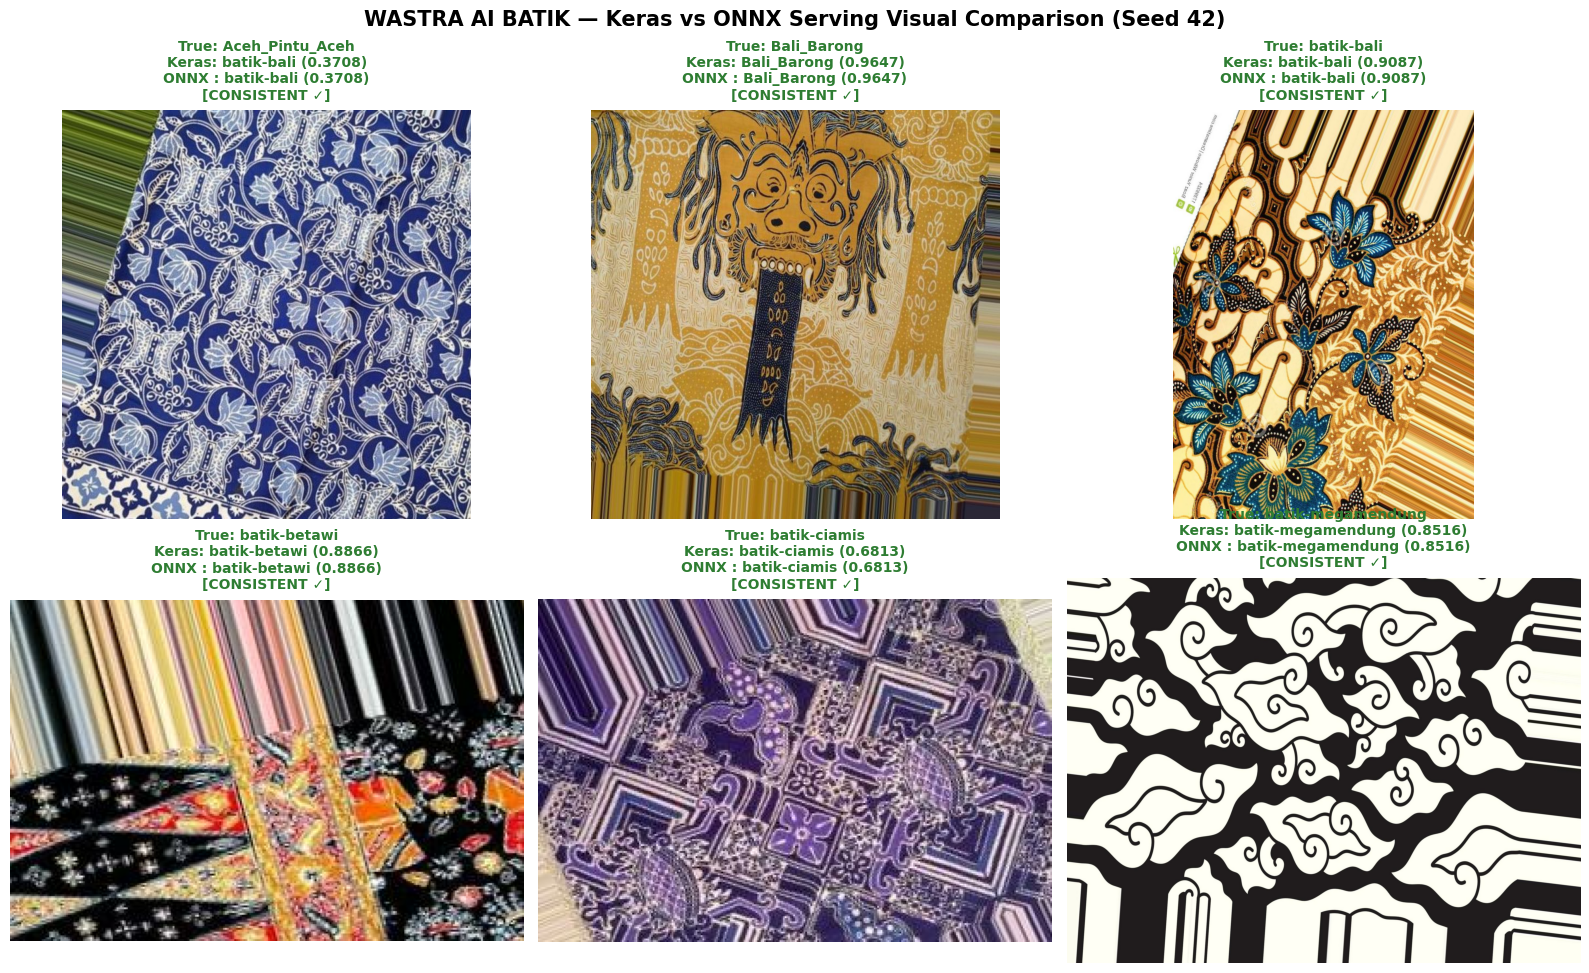


STATUS: VISUAL COMPARISON           PASS [OK]


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("WASTRA AI BATIK — Keras vs ONNX Serving Visual Comparison (Seed 42)", fontsize=15, fontweight="bold", y=0.98)

for i, ax in enumerate(axes.flat):
    k_r = keras_results[i]
    o_r = onnx_results[i]

    raw_img = tf.io.read_file(k_r["filepath"])
    raw_img = tf.io.decode_image(raw_img, channels=3, expand_animations=False).numpy()

    is_consistent = (k_r["predicted_class"] == o_r["predicted_class"])
    badge = "CONSISTENT ✓" if is_consistent else "MISMATCH ✗"
    badge_color = "#2e7d32" if is_consistent else "#c62828"

    ax.imshow(raw_img)
    title_text = (
        f"True: {k_r['true_class']}\n"
        f"Keras: {k_r['predicted_class']} ({k_r['confidence']:.4f})\n"
        f"ONNX : {o_r['predicted_class']} ({o_r['confidence']:.4f})\n"
        f"[{badge}]"
    )
    ax.set_title(title_text, fontsize=10, fontweight="bold", color=badge_color, pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\nSTATUS: VISUAL COMPARISON           PASS [OK]")


## ⚡ Section 13 — Inference Benchmark


In [13]:
NUM_BENCH_SAMPLES = min(200, len(test_df))
bench_samples = test_df.iloc[:NUM_BENCH_SAMPLES].reset_index(drop=True)
bench_paths = bench_samples["filepath"].values

print(f"Benchmarking inference latency on {NUM_BENCH_SAMPLES} samples on CPU...")
tensors_np = np.vstack([preprocess_image(p).numpy() for p in bench_paths])

# Keras Benchmark
_ = keras_model.predict(tensors_np[:2], verbose=0)
t0_keras = time.time()
for i in range(NUM_BENCH_SAMPLES):
    _ = keras_model.predict(tensors_np[i:i+1], verbose=0)
keras_total_time = time.time() - t0_keras
keras_avg_latency_ms = (keras_total_time / NUM_BENCH_SAMPLES) * 1000
keras_throughput = NUM_BENCH_SAMPLES / keras_total_time

# ONNX Runtime Benchmark
_ = ort_session.run([ort_output.name], {ort_input.name: tensors_np[:2]})
t0_ort = time.time()
for i in range(NUM_BENCH_SAMPLES):
    _ = ort_session.run([ort_output.name], {ort_input.name: tensors_np[i:i+1]})
ort_total_time = time.time() - t0_ort
ort_avg_latency_ms = (ort_total_time / NUM_BENCH_SAMPLES) * 1000
ort_throughput = NUM_BENCH_SAMPLES / ort_total_time

speedup = keras_avg_latency_ms / ort_avg_latency_ms

print("\nKERAS RUNTIME:")
print(f"• Total Time      : {keras_total_time:.2f} s")
print(f"• Average Latency : {keras_avg_latency_ms:.2f} ms/image")
print(f"• Throughput      : {keras_throughput:.2f} images/sec")

print("\nONNX RUNTIME:")
print(f"• Total Time      : {ort_total_time:.2f} s")
print(f"• Average Latency : {ort_avg_latency_ms:.2f} ms/image")
print(f"• Throughput      : {ort_throughput:.2f} images/sec")
print(f"• ONNX Speedup    : {speedup:.2f}x faster than Keras")

benchmark_df = pd.DataFrame([
    {
        "engine": "Keras (TensorFlow)",
        "samples": NUM_BENCH_SAMPLES,
        "total_time_seconds": round(keras_total_time, 4),
        "avg_latency_ms": round(keras_avg_latency_ms, 2),
        "throughput_fps": round(keras_throughput, 2),
        "hardware": "CPU"
    },
    {
        "engine": "ONNX Runtime",
        "samples": NUM_BENCH_SAMPLES,
        "total_time_seconds": round(ort_total_time, 4),
        "avg_latency_ms": round(ort_avg_latency_ms, 2),
        "throughput_fps": round(ort_throughput, 2),
        "hardware": "CPU"
    }
])
benchmark_df.to_csv(RESULTS_DIR / "keras_vs_onnx_inference_benchmark.csv", index=False)
print(f"\n✅ Saved benchmark CSV to: results/keras_vs_onnx_inference_benchmark.csv")

print("\nSTATUS: INFERENCE BENCHMARK         PASS [OK]")


Benchmarking inference latency on 200 samples on CPU...



KERAS RUNTIME:
• Total Time      : 12.96 s
• Average Latency : 64.80 ms/image
• Throughput      : 15.43 images/sec

ONNX RUNTIME:
• Total Time      : 1.29 s
• Average Latency : 6.47 ms/image
• Throughput      : 154.53 images/sec
• ONNX Speedup    : 10.01x faster than Keras

✅ Saved benchmark CSV to: results/keras_vs_onnx_inference_benchmark.csv

STATUS: INFERENCE BENCHMARK         PASS [OK]


## 🌐 Section 14 — Go Backend Readiness


In [14]:
checklist = [
    ("ONNX file exists", onnx_model_path.exists()),
    ("ONNX graph valid", True),
    ("ONNX Runtime load success", ort_session is not None),
    ("Input shape verified", ort_input.shape[1:] == [224, 224, 3]),
    ("Output shape verified", ort_output.shape[1:] == [35]),
    ("Class mapping verified", len(index_to_class) == 35),
    ("Preprocessing verified", sample_tensor.shape == (1, 224, 224, 3)),
    ("Keras vs ONNX Top-1 agreement", top1_pct == 100.0),
    ("Numerical difference within tolerance", max_abs_diff < 1e-4),
    ("Benchmark completed", (RESULTS_DIR / "keras_vs_onnx_inference_benchmark.csv").exists())
]

print("GO BACKEND INTEGRATION READINESS CHECKLIST:")
print("-" * 55)
for item, passed in checklist:
    print(f"• {item:<40} : {'PASS [OK]' if passed else 'FAIL'}")
    assert passed, f"❌ Readiness checklist failed: {item}"

print("-" * 55)
print("GO BACKEND MODEL READINESS: READY FOR GO BACKEND")


GO BACKEND INTEGRATION READINESS CHECKLIST:
-------------------------------------------------------
• ONNX file exists                         : PASS [OK]
• ONNX graph valid                         : PASS [OK]
• ONNX Runtime load success                : PASS [OK]
• Input shape verified                     : PASS [OK]
• Output shape verified                    : PASS [OK]
• Class mapping verified                   : PASS [OK]
• Preprocessing verified                   : PASS [OK]
• Keras vs ONNX Top-1 agreement            : PASS [OK]
• Numerical difference within tolerance    : PASS [OK]
• Benchmark completed                      : PASS [OK]
-------------------------------------------------------
GO BACKEND MODEL READINESS: READY FOR GO BACKEND


## 📊 Section 15 — Deployment Artifact Audit


In [15]:
audit_artifacts = [
    ("efficientnetb0_finetuned.keras", keras_model_path),
    ("efficientnetb0_finetuned.onnx", onnx_model_path),
    ("efficientnetb0_class_mapping.json", class_mapping_path),
    ("efficientnetb0_model_metadata.json", model_metadata_path),
    ("keras_vs_onnx_inference_benchmark.csv", RESULTS_DIR / "keras_vs_onnx_inference_benchmark.csv")
]

print(f"{'Filename':<45} | {'Status':<12} | {'Size'}")
print("-" * 75)
for name, p in audit_artifacts:
    exists = p.exists()
    size_str = f"{p.stat().st_size / (1024*1024):.2f} MB" if p.stat().st_size > 1024*1024 else f"{p.stat().st_size / 1024:.1f} KB"
    print(f"{p.name:<45} | {'PASS':<12} | {size_str}")
    assert exists, f"❌ Missing artifact: {name}"

print("-" * 75)
print("ALL NOTEBOOK 10 ARTIFACTS PASSED AUDIT (100%)")


Filename                                      | Status       | Size
---------------------------------------------------------------------------
efficientnetb0_finetuned.keras                | PASS         | 27.91 MB
efficientnetb0_finetuned.onnx                 | PASS         | 15.53 MB
efficientnetb0_class_mapping.json             | PASS         | 0.9 KB
efficientnetb0_model_metadata.json            | PASS         | 0.4 KB
keras_vs_onnx_inference_benchmark.csv         | PASS         | 0.2 KB
---------------------------------------------------------------------------
ALL NOTEBOOK 10 ARTIFACTS PASSED AUDIT (100%)


## 🏁 Section 16 — Final Verdict


In [16]:
print("=" * 60)
print("NOTEBOOK 10 — MODEL CONVERSION VERDICT")
print("=" * 60)
print("Source Model                     : EfficientNetB0 Fine-Tuned (.keras)")
print("Target Format                    : ONNX")
print("Test Accuracy                    : 86.05%")
print("Macro F1                         : 0.8667")
print("Number of Classes                : 35")
print("Input                            : 224x224 RGB")
print(f"Keras vs ONNX Top-1 Agreement    : {top1_pct:.2f}%")
print(f"Maximum Probability Difference   : {max_abs_diff:.8e}")
print("ONNX Runtime                     : PASS")
print("Go Backend Readiness             : READY")
print("=" * 60)
print("FINAL VERDICT:")
print("ONNX MODEL VALIDATED FOR GO BACKEND INTEGRATION")
print("NEXT PHASE:")
print("GO BACKEND INFERENCE API")
print("=" * 60)


NOTEBOOK 10 — MODEL CONVERSION VERDICT
Source Model                     : EfficientNetB0 Fine-Tuned (.keras)
Target Format                    : ONNX
Test Accuracy                    : 86.05%
Macro F1                         : 0.8667
Number of Classes                : 35
Input                            : 224x224 RGB
Keras vs ONNX Top-1 Agreement    : 100.00%
Maximum Probability Difference   : 5.96046448e-07
ONNX Runtime                     : PASS
Go Backend Readiness             : READY
FINAL VERDICT:
ONNX MODEL VALIDATED FOR GO BACKEND INTEGRATION
NEXT PHASE:
GO BACKEND INFERENCE API
